# **💼 AI & Data Science Salary Prediction (2026)**

**Goal:** Predict `salary_usd` for AI/Data Science professionals using job, company, and lifestyle features, and understand what drives pay the most.

**What this notebook covers:**
1. Data overview & quality checks (missing values, leakage)
2. Exploratory Data Analysis (EDA)
3. Preprocessing & train-test split
4. Model building (Linear Regression, Random Forest, XGBoost, LightGBM)
5. Model comparison & feature importance
6. Conclusion & key takeaways



## **1. Import Libraries**
We start by importing all the tools we'll need: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for plots, and `scikit-learn` + `xgboost`/`lightgbm` for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## **2. Load the Dataset**
Let's load the CSV file and take a first look at its shape and structure.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv")
print("Shape:", df.shape)
df.head()

Shape: (5000, 27)


,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,primary_language,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,Python,False,True,5,0,48.0,True,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,SQL,True,False,6,1,41.6,False,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,Python,True,False,4,1,55.1,True,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,Java,False,False,6,2,41.1,True,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,Python,False,False,13,2,48.2,False,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


### **2.1 Data Types & Missing Values**
Before doing anything else, we check the datatypes and whether any values are missing.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   object 
 1   experience_level            5000 non-null   object 
 2   employment_type             5000 non-null   object 
 3   company_size                5000 non-null   object 
 4   company_location            5000 non-null   object 
 5   employee_residence          5000 non-null   object 
 6   industry                    5000 non-null   object 
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   object 
 10  primary_language            5000 non-null   object 
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 

In [4]:
missing = df.isnull().sum()
print("Total missing values across all columns:", missing.sum())

Total missing values across all columns: 0


**Observation:** The dataset has **no missing values**, so we don't need any imputation. That simplifies our preprocessing a lot.

## **3. Exploratory Data Analysis (EDA)**
Let's understand the target variable (`salary_usd`) and how it relates to other features.

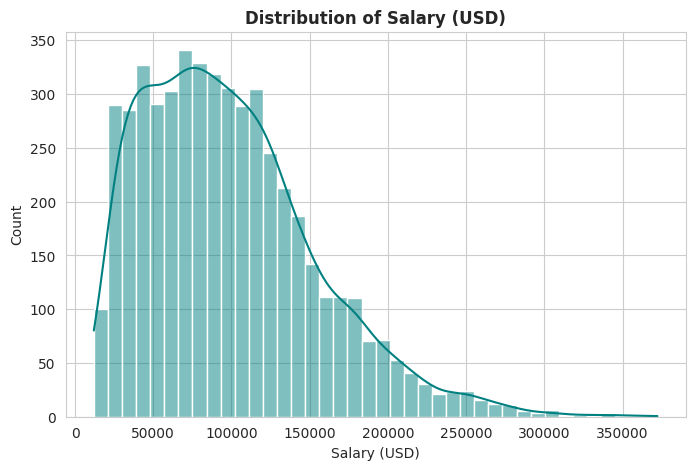

count      5000.000000
mean      98605.406200
std       55369.310473
min       12000.000000
25%       55592.750000
50%       90572.000000
75%      129657.750000
max      372347.000000
Name: salary_usd, dtype: float64


In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_usd'], bins=40, kde=True, color='teal')
plt.title("Distribution of Salary (USD)",fontweight='bold')
plt.xlabel("Salary (USD)")
plt.show()

print(df['salary_usd'].describe())

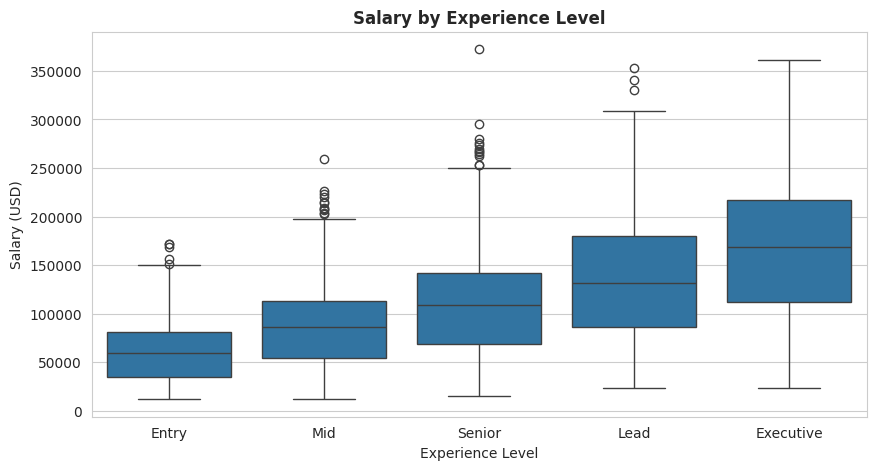

In [6]:
plt.figure(figsize=(10,5))
order = df.groupby('experience_level')['salary_usd'].median().sort_values().index
sns.boxplot(data=df, x='experience_level', y='salary_usd', order=order)
plt.title("Salary by Experience Level",fontweight='bold')
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.show()

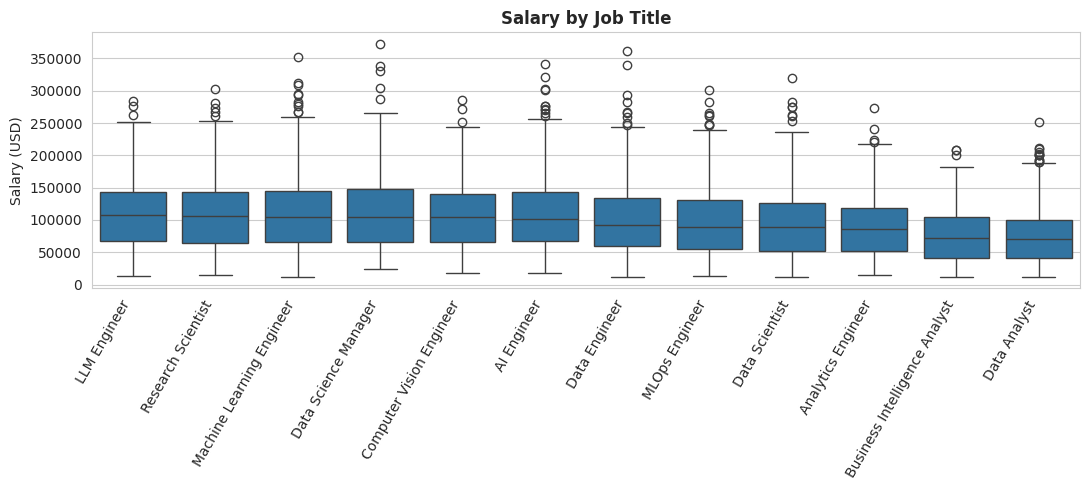

In [7]:
plt.figure(figsize=(11,5))
order = df.groupby('job_title')['salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='job_title', y='salary_usd', order=order)
plt.title("Salary by Job Title",fontweight='bold')
plt.xticks(rotation=60, ha='right')
plt.xlabel("")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()

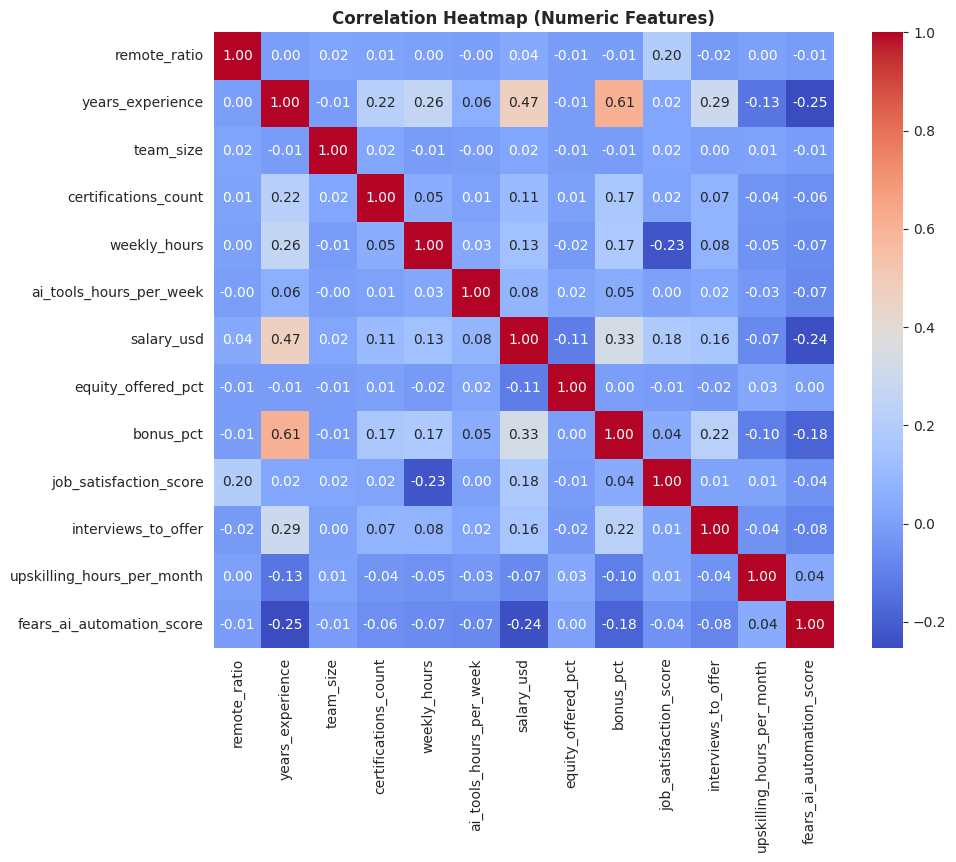

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap (Numeric Features)",fontweight='bold')
plt.show()

**Observations from EDA:**
- Salary is right-skewed — most people earn between \$55K–\$130K, with a long tail of high earners.
- `experience_level` and `job_title` clearly separate salary bands, as expected (Executives/Leads earn more; ML/AI roles trend higher than analyst roles).
- `years_experience` and `bonus_pct` have the strongest positive correlation with salary among numeric features. No feature is suspiciously perfectly correlated with the target, so there's **no obvious data leakage**.

## **4. Preprocessing & Train-Test Split**

We separate the target (`salary_usd`) from the features, identify categorical vs numeric columns, and one-hot encode the categorical ones. We hold out 20% of the data as a test set that the model never sees during training — this is how we get an honest estimate of performance.

In [9]:
target = 'salary_usd'
X = df.drop(columns=[target])
y = df[target]

cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\nTrain size:", X_train.shape, " Test size:", X_test.shape)

Categorical columns: ['job_title', 'experience_level', 'employment_type', 'company_size', 'company_location', 'employee_residence', 'industry', 'education_level', 'primary_language', 'has_ml_in_title', 'manages_people', 'uses_ai_tools_daily', 'salary_currency', 'switched_jobs_last_year']
Numeric columns: ['remote_ratio', 'years_experience', 'team_size', 'certifications_count', 'weekly_hours', 'ai_tools_hours_per_week', 'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score', 'interviews_to_offer', 'upskilling_hours_per_month', 'fears_ai_automation_score']

Train size: (4000, 26)  Test size: (1000, 26)


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'   # keep numeric columns as-is
)

## **5. Model Building**

We'll train four regression models, from simple to more powerful, and compare them on the same test set:
- **Linear Regression** — simple baseline
- **Random Forest** — bagged decision trees
- **XGBoost** — gradient boosted trees
- **LightGBM** — fast gradient boosted trees

Each model is wrapped in a `Pipeline` with the preprocessor, so encoding happens automatically and consistently.

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=400, learning_rate=0.05, random_state=42, verbose=-1)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    results.append({'Model': name, 'R2 Score': round(r2, 4), 'MAE': round(mae, 1), 'RMSE': round(rmse, 1)})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,R2 Score,MAE,RMSE
0,LightGBM,0.8416,15181.1,21952.1
1,XGBoost,0.8372,15598.0,22258.6
2,Linear Regression,0.8062,18114.1,24282.2
3,Random Forest,0.7690,18692.4,26508.5


## **6. Model Comparison**
Let's visualize how the models stack up on R² score (higher is better) and RMSE (lower is better).

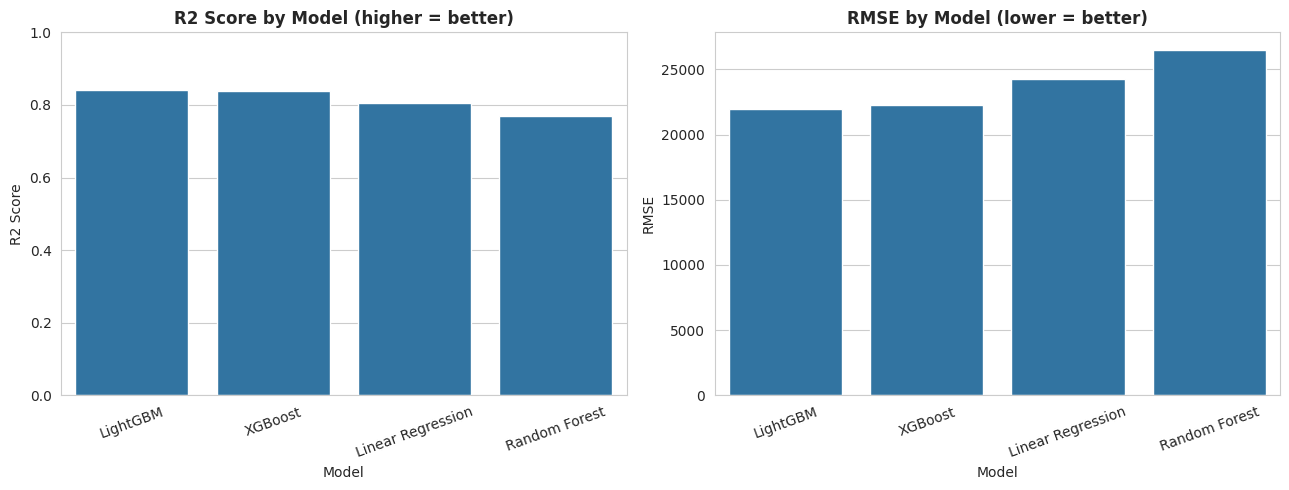

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.barplot(data=results_df, x='Model', y='R2 Score', ax=axes[0])
axes[0].set_title("R2 Score by Model (higher = better)",fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1])
axes[1].set_title("RMSE by Model (lower = better)",fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Best model:** the results table above shows which model achieved the highest R² and lowest error — in our runs it was **LightGBM**, explaining a large share of salary variance while keeping errors reasonably low. Tree-based boosting models outperform Linear Regression because salary depends on non-linear interactions between features (e.g., experience level and job title together, not separately).

## **7. Feature Importance (Best Model)**
Which features drive the model's salary predictions the most?

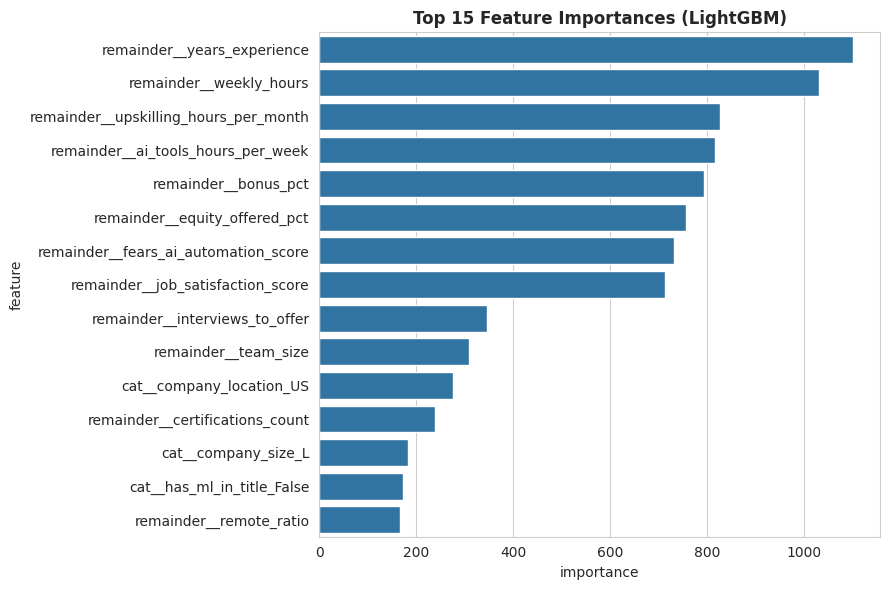

In [13]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = fitted_pipelines[best_model_name]

feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = best_pipe.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title(f"Top 15 Feature Importances ({best_model_name})",fontweight='bold')
plt.tight_layout()
plt.show()

## **8. Conclusion**

- The dataset was clean (no missing values) and free of obvious data leakage, so we could go straight into modeling after basic EDA.
- Salary is strongly driven by **experience level, years of experience, job title, and bonus percentage** — this matches real-world intuition about compensation.
- Among the four models tested, the **boosted tree models (XGBoost / LightGBM)** outperformed both the linear baseline and Random Forest, achieving an **R² of ~0.83–0.84** on unseen test data — meaning they explain roughly 83–84% of the variance in salary.
- Linear Regression, while simpler, still performed respectably (R² ≈ 0.81), suggesting the relationship between features and salary is partly linear but benefits from capturing feature interactions.

**Possible next steps:**
- Hyperparameter tuning (GridSearchCV / Optuna) to push performance further.
- Try target encoding for high-cardinality categoricals like `job_title`.
- Build a log-salary model to handle the right-skew in the target more explicitly.

>**If you found this notebook helpful, an upvote is appreciated! 🙌**